<a href="https://colab.research.google.com/github/ravalikavellidandla/Project_4/blob/main/Feature_Extraction_and_Price_Prediction_for_mobile_phones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
# OBJECTIVE 1 : IMPORT LIBRARIES
# =====================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [ ]:
# =====================================================================
# OBJECTIVE 2 : LOAD DATASET
# =====================================================================

df = pd.read_excel("/content/Processed_Flipdata.xlsx")

print("Dataset loaded successfully.")
print("Original shape:", df.shape)


Dataset loaded successfully.
Original shape: (541, 12)


In [ ]:
# =====================================================================
# OBJECTIVE 3 : REMOVE UNWANTED INDEX COLUMN
# =====================================================================

# Remove the first unwanted index column from the Excel file
df = df.drop(df.columns[0], axis=1)

print("Shape after removing unwanted index column:", df.shape)
print("Columns:")
print(df.columns.tolist())


Shape after removing unwanted index column: (541, 11)
Columns:
['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize']


In [ ]:
# =====================================================================
# OBJECTIVE 4 : BASIC DATA EXPLORATION
# =====================================================================

print("\n=== OBJECTIVE 4: BASIC DATA EXPLORATION ===")

print("\n--- Dataset Information ---")
df.info()

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Last 5 Rows ---")
print(df.tail())

print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- Statistical Description ---")
print(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())



=== OBJECTIVE 4: BASIC DATA EXPLORATION ===

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    object 
 1   Colour         541 non-null    object 
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    object 
 6   Front Camera   541 non-null    object 
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    object 
 10  Prize          541 non-null    int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 46.6+ KB

--- First 5 Rows ---
             Model        Colour  Memory  RAM  Battery_ Rear Camera  \
0  Infinix SMART 7   Night Black      64    4      6000        13MP   
1  Infinix SMART 7    

In [ ]:
# =====================================================================
# OBJECTIVE 5 : DATA CLEANING
# =====================================================================

print("\n=== OBJECTIVE 5: DATA CLEANING ===")

# Remove duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows before removal:", duplicate_count)

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

# Remove missing values
missing_before = df.isnull().sum().sum()
print("Missing values before removal:", missing_before)

df.dropna(inplace=True)

print("Shape after removing missing values:", df.shape)
print("Missing values after cleaning:", df.isnull().sum().sum())

# Convert camera columns from text such as '13MP' to numeric values.
# This is done before EDA so these variables can also be analysed numerically.
for col in ["Rear Camera", "Front Camera"]:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
            .str.replace("MP", "", regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows created as invalid values during conversion
df.dropna(inplace=True)

print("\nData types after cleaning/conversion:")
print(df.dtypes)



=== OBJECTIVE 5: DATA CLEANING ===
Duplicate rows before removal: 10
Shape after removing duplicates: (531, 11)
Missing values before removal: 0
Shape after removing missing values: (531, 11)
Missing values after cleaning: 0

Data types after cleaning/conversion:
Model             object
Colour            object
Memory             int64
RAM                int64
Battery_           int64
Rear Camera        int64
Front Camera       int64
AI Lens            int64
Mobile Height    float64
Processor_        object
Prize              int64
dtype: object


## Objective 6: Exploratory Data Analysis (EDA)

EDA is performed **before encoding**, so categorical variables such as Model, Colour, and Processor remain understandable in the graphs.



=== OBJECTIVE 6.1: UNIVARIATE ANALYSIS ===


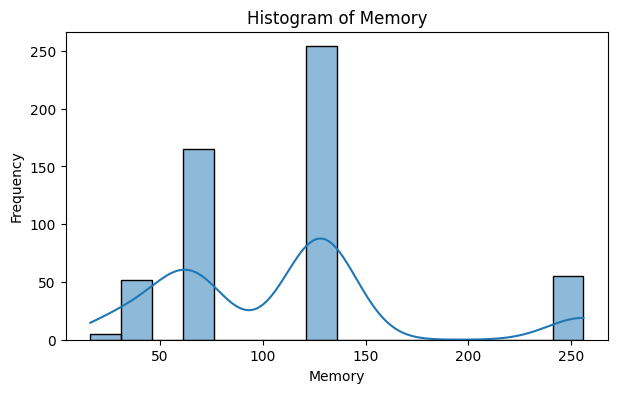

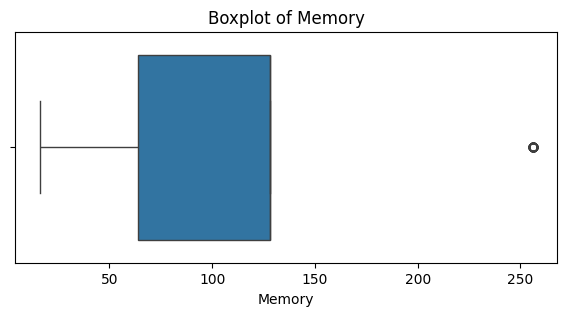

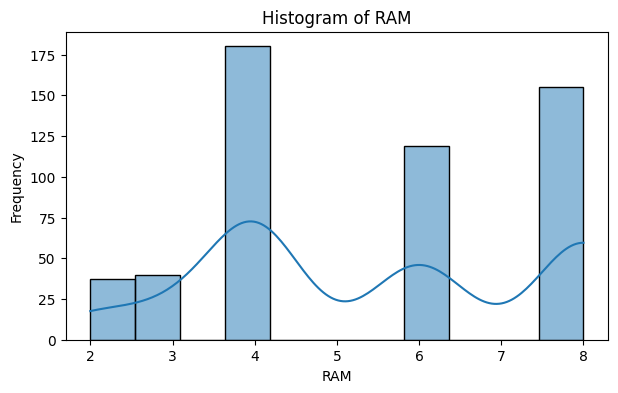

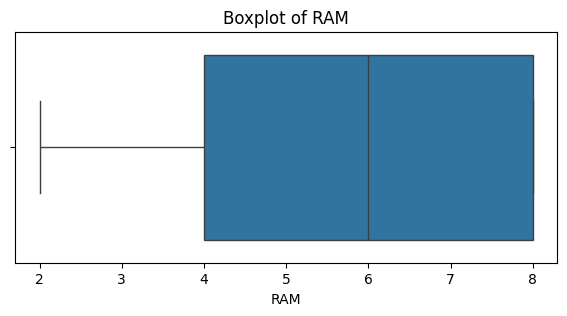

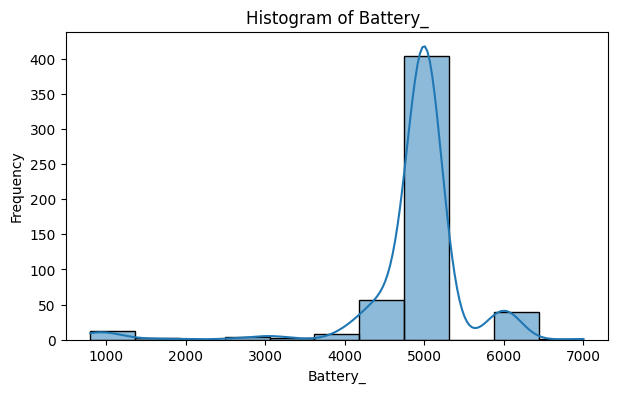

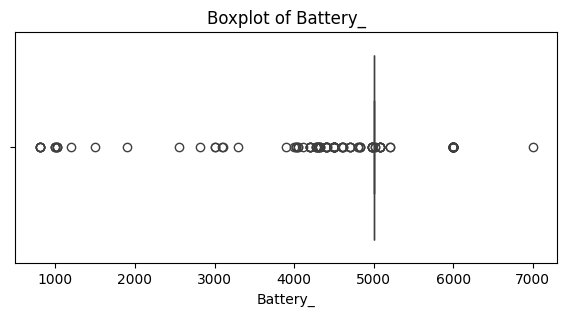

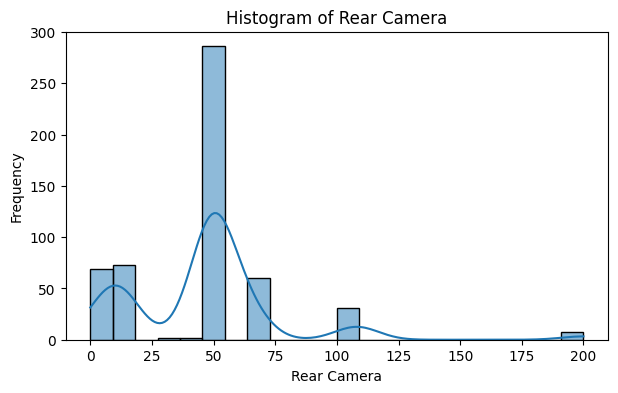

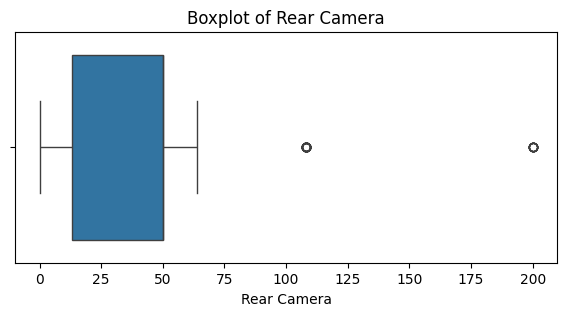

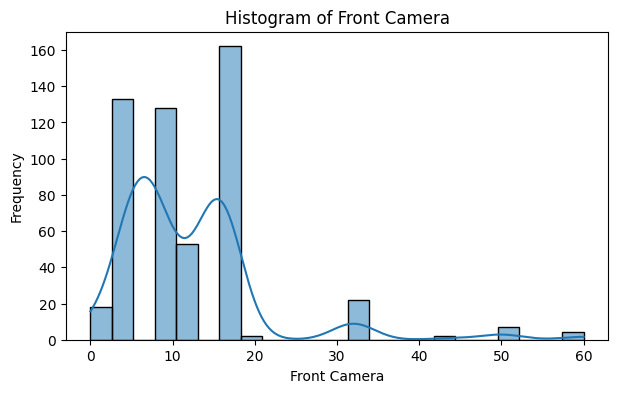

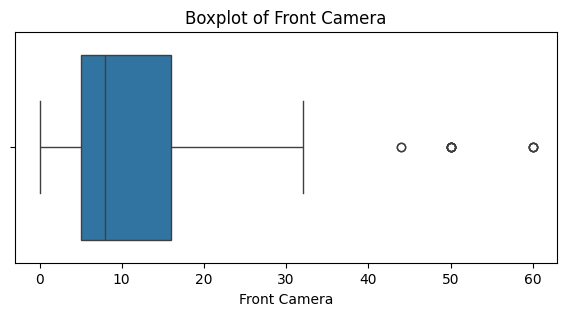

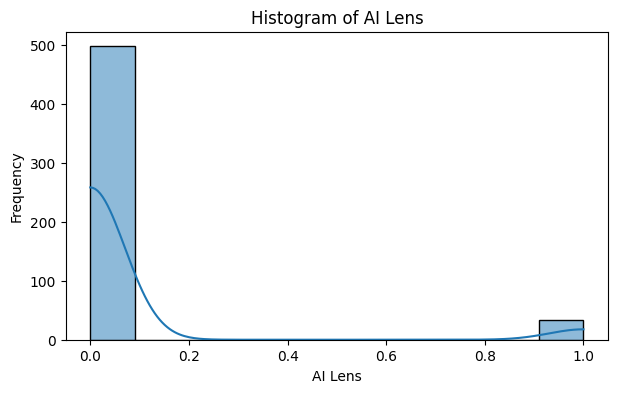

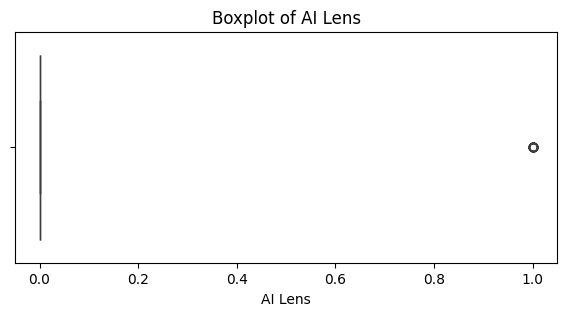

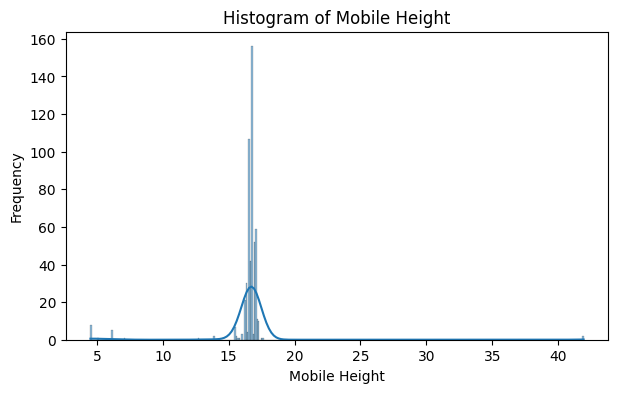

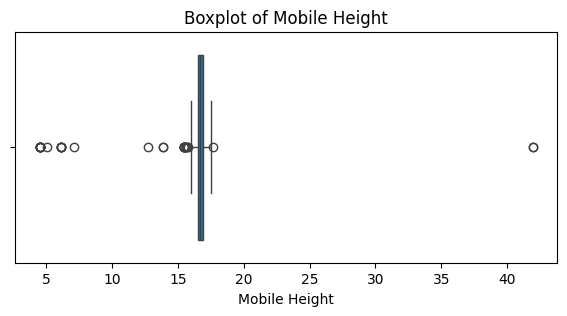

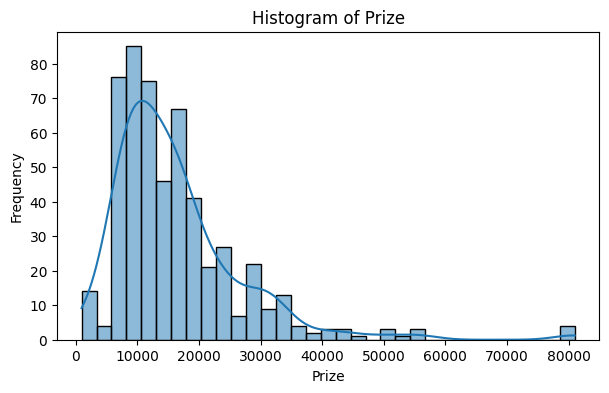

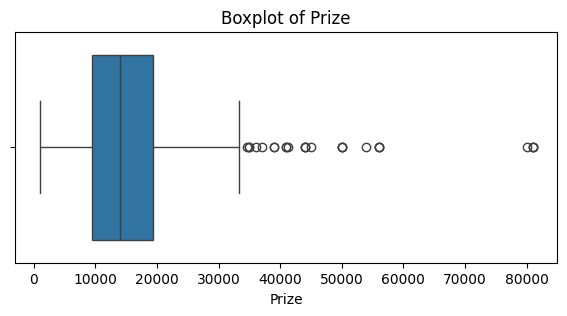

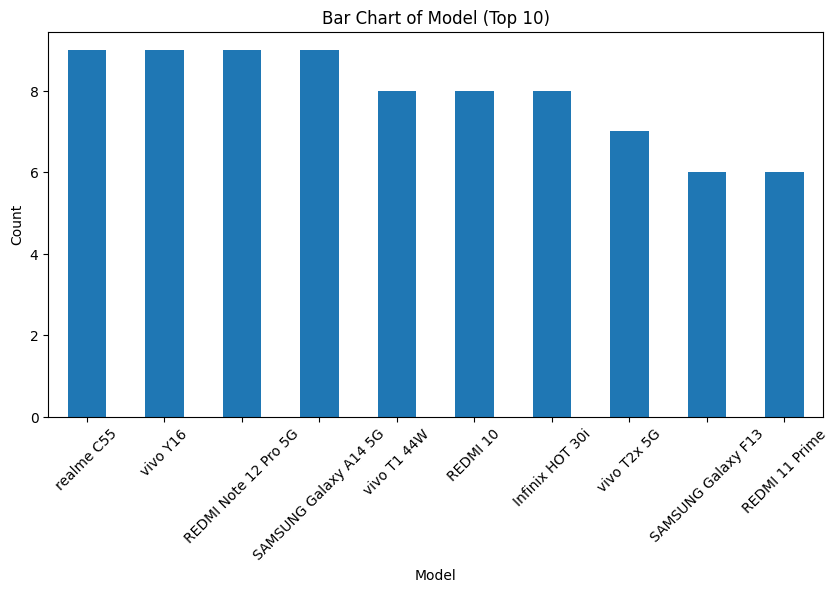

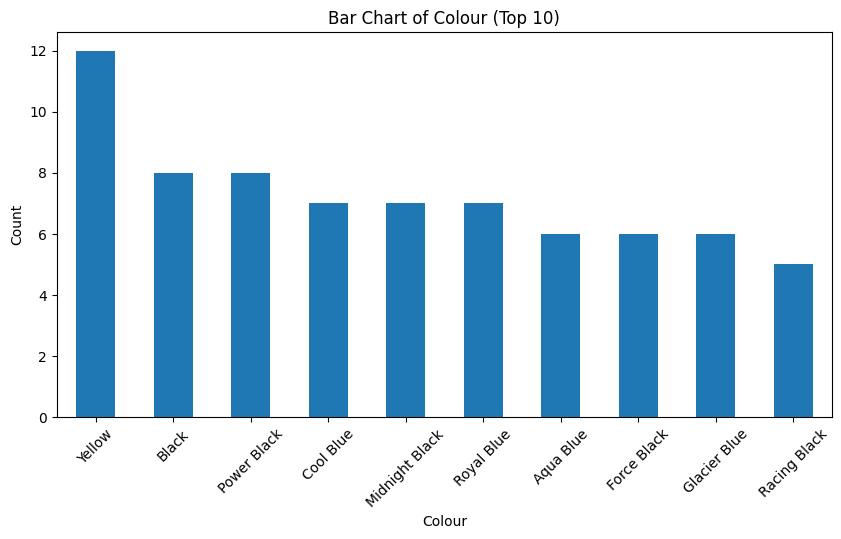

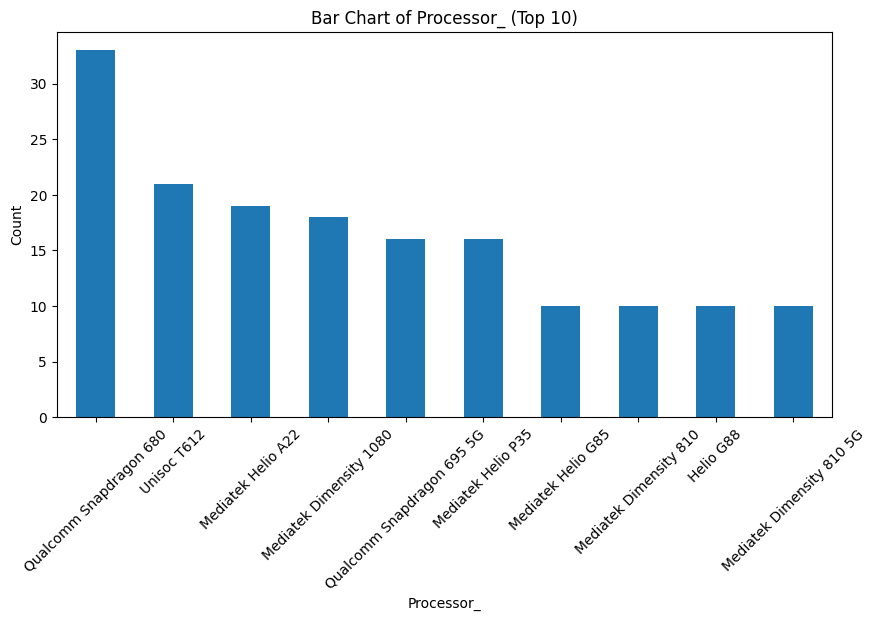

In [ ]:
# =====================================================================
# OBJECTIVE 6.1 : UNIVARIATE ANALYSIS
# =====================================================================

print("\n=== OBJECTIVE 6.1: UNIVARIATE ANALYSIS ===")

# Numerical variables
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

# Categorical variables
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Bar Chart of {col} (Top 10)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
# =====================================================================
# OBJECTIVE 6.2 : OUTLIER DETECTION AND HANDLING
# =====================================================================

print("\n=== OBJECTIVE 6.2: OUTLIER DETECTION AND HANDLING ===")

# Recalculate numeric columns after camera conversion
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()
    outlier_counts[col] = int(outliers)

    print(f"{col}: {outliers} outliers")
    print(f"Lower limit: {lower_limit:.2f}")
    print(f"Upper limit: {upper_limit:.2f}")
    print("-" * 50)

# Handle outliers in predictor variables using IQR capping.
# Prize is intentionally not capped because high-priced phones can be valid observations.
predictor_numeric_cols = [
    col for col in numeric_cols
    if col != "Prize"
]

for col in predictor_numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

print("\nOutlier handling completed using IQR capping for predictor variables.")

print("***" * 30)


=== OBJECTIVE 6.2: OUTLIER DETECTION AND HANDLING ===
Memory: 55 outliers
Lower limit: -32.00
Upper limit: 224.00
--------------------------------------------------
RAM: 0 outliers
Lower limit: -2.00
Upper limit: 14.00
--------------------------------------------------
Battery_: 148 outliers
Lower limit: 5000.00
Upper limit: 5000.00
--------------------------------------------------
Rear Camera: 39 outliers
Lower limit: -42.50
Upper limit: 105.50
--------------------------------------------------
Front Camera: 13 outliers
Lower limit: -11.50
Upper limit: 32.50
--------------------------------------------------
AI Lens: 34 outliers
Lower limit: 0.00
Upper limit: 0.00
--------------------------------------------------
Mobile Height: 32 outliers
Lower limit: 15.87
Upper limit: 17.59
--------------------------------------------------
Prize: 25 outliers
Lower limit: -5587.75
Upper limit: 34294.25
--------------------------------------------------

Outlier handling completed using IQR cappi

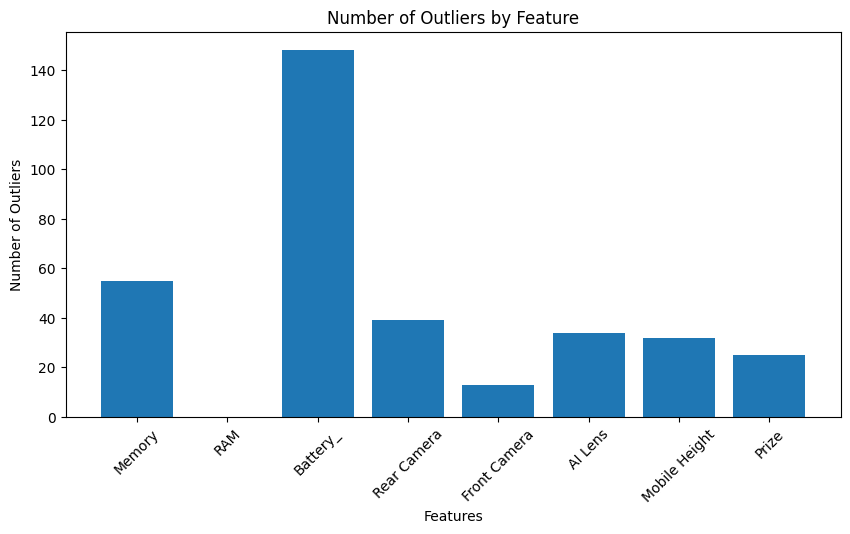

In [ ]:
# =====================================================================
# OUTLIER COUNT GRAPH
# =====================================================================

plt.figure(figsize=(10, 5))
plt.bar(outlier_counts.keys(), outlier_counts.values())
plt.title("Number of Outliers by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Outliers")
plt.xticks(rotation=45)
plt.show()



=== OBJECTIVE 6.3: BIVARIATE ANALYSIS ===


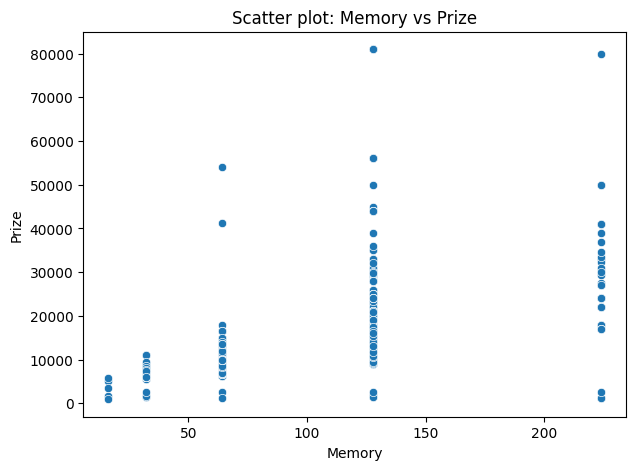

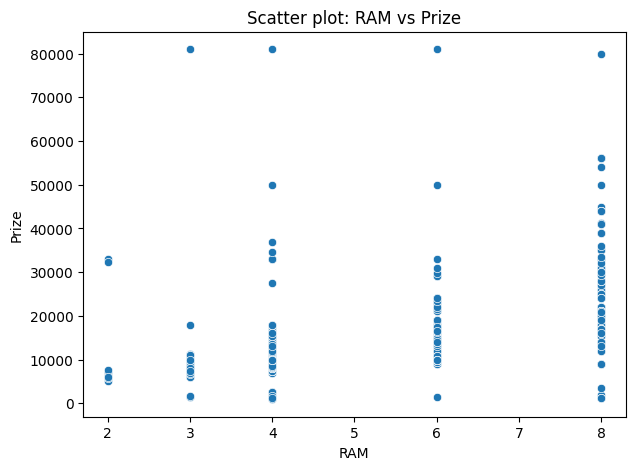

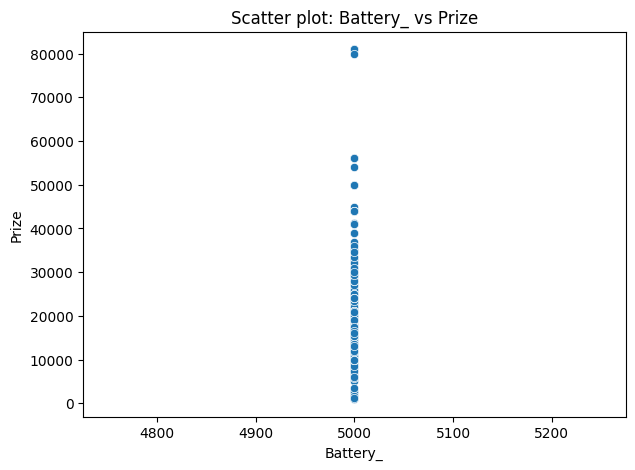

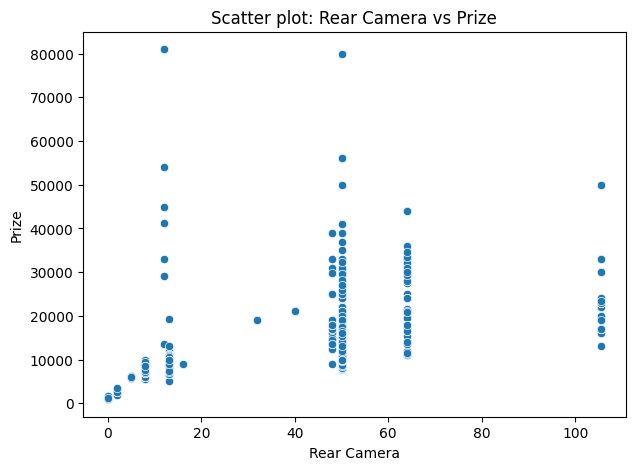

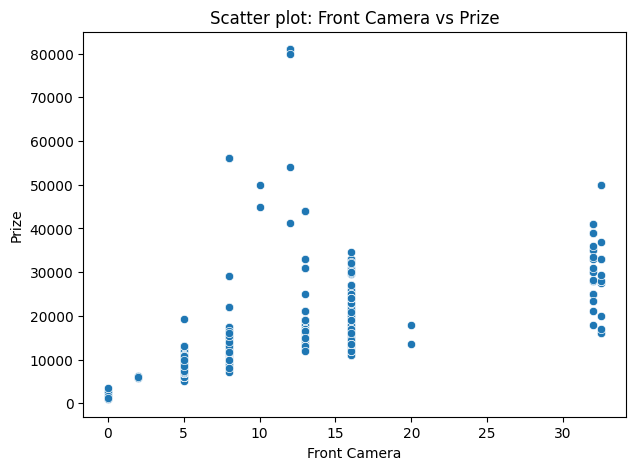

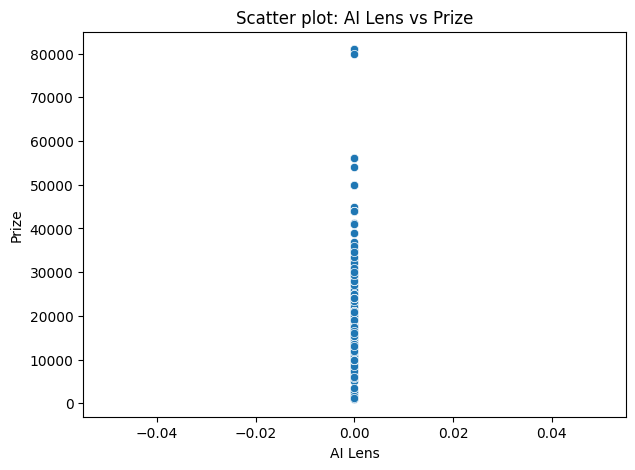

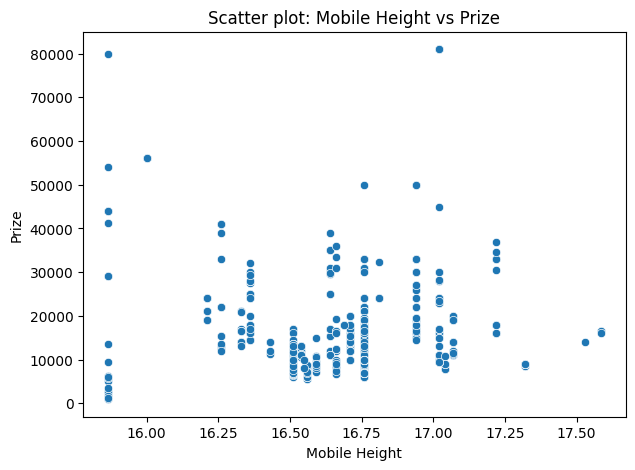

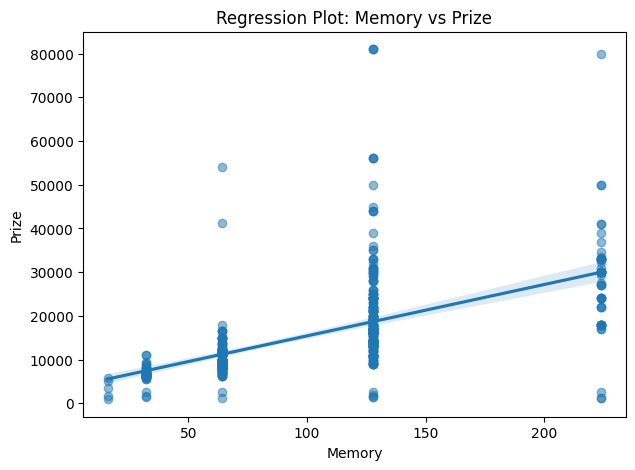

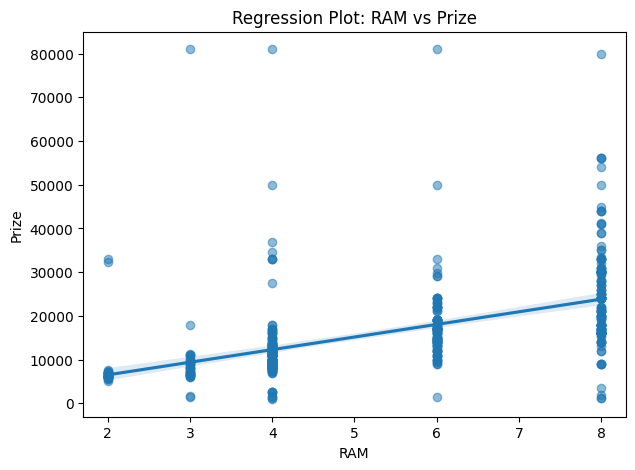

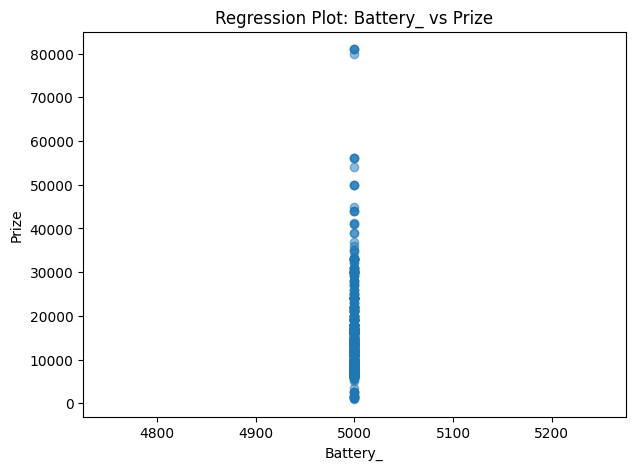

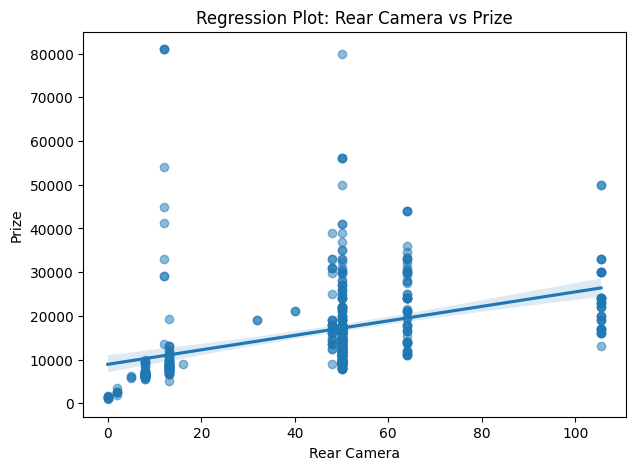

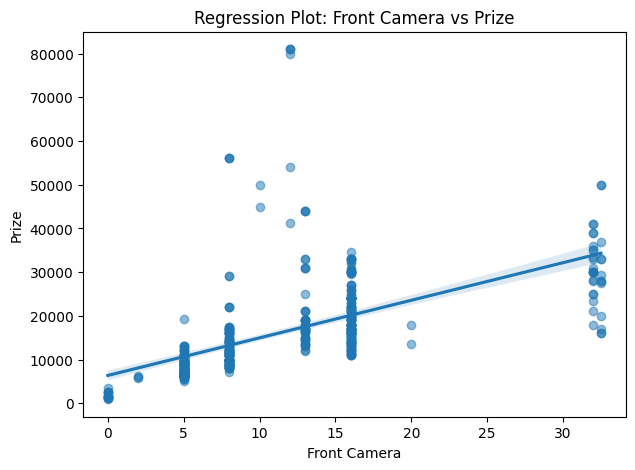

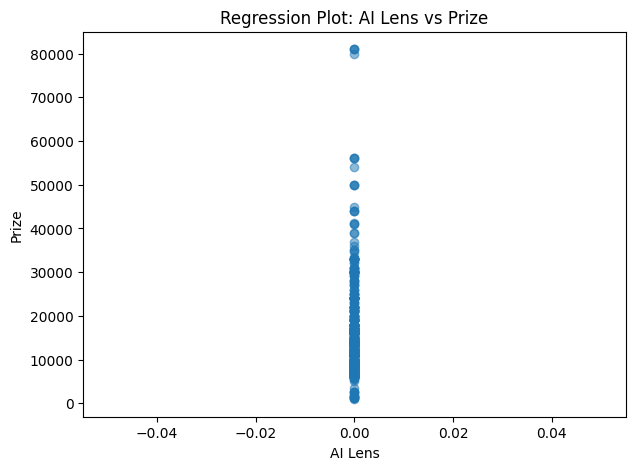

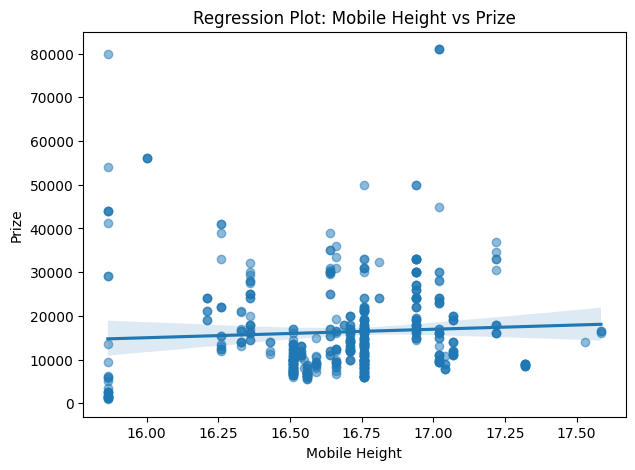

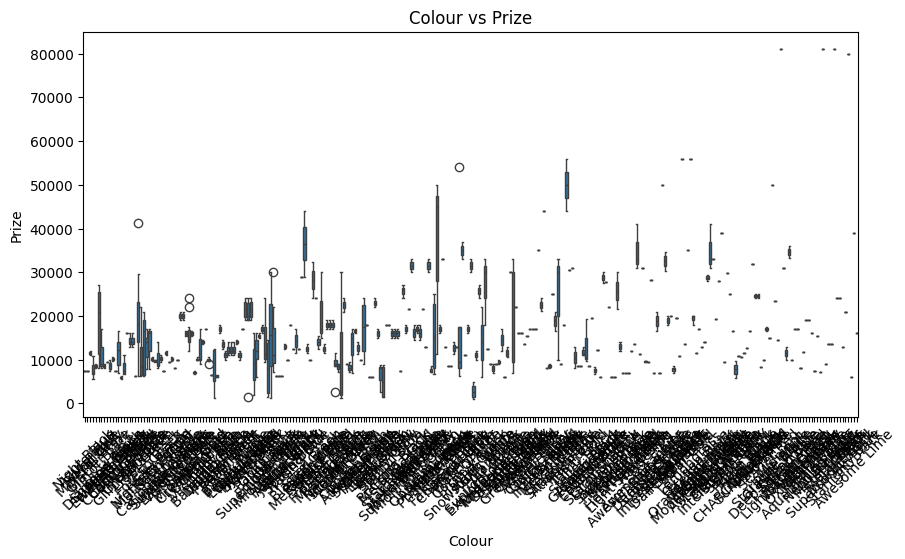

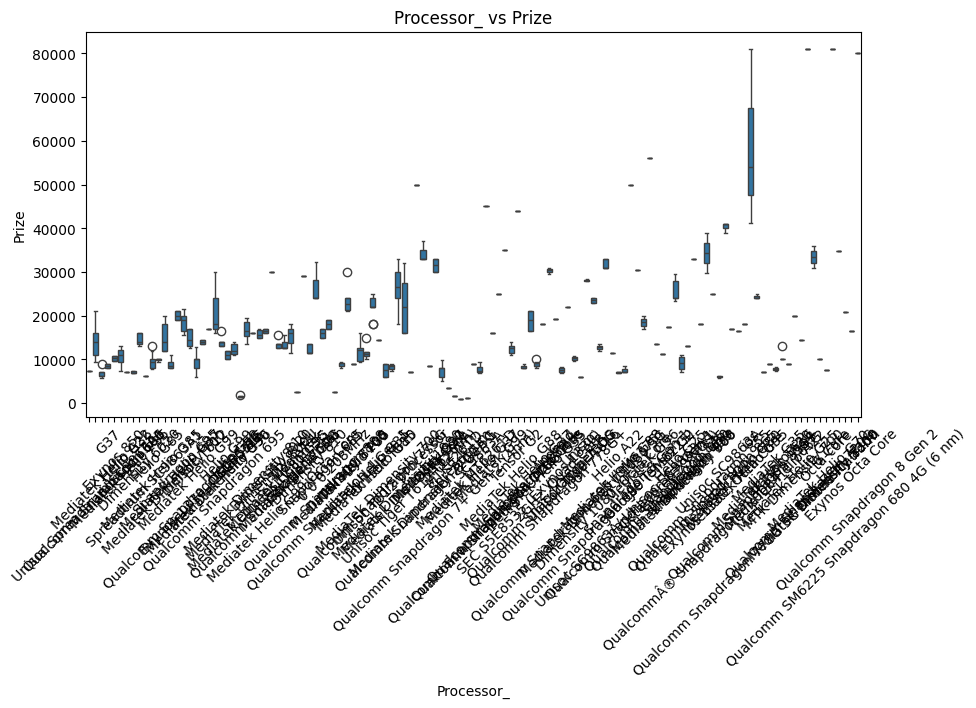

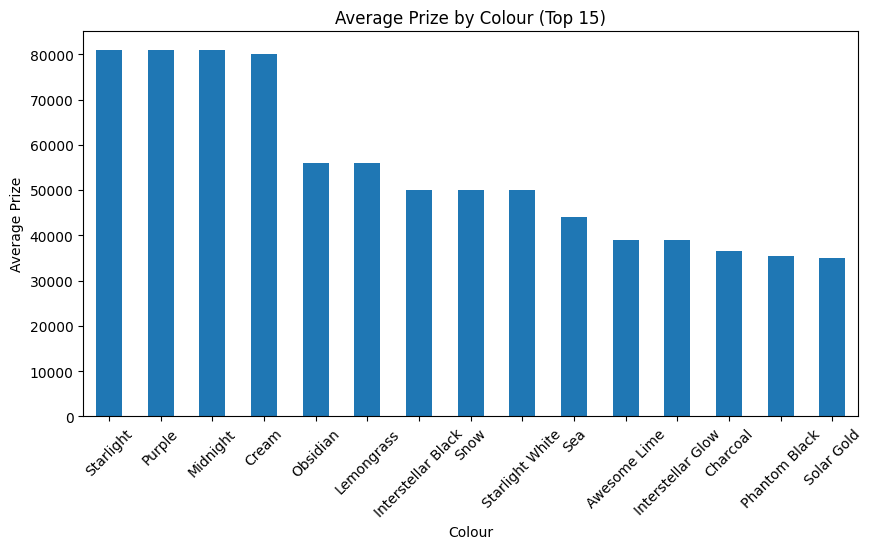

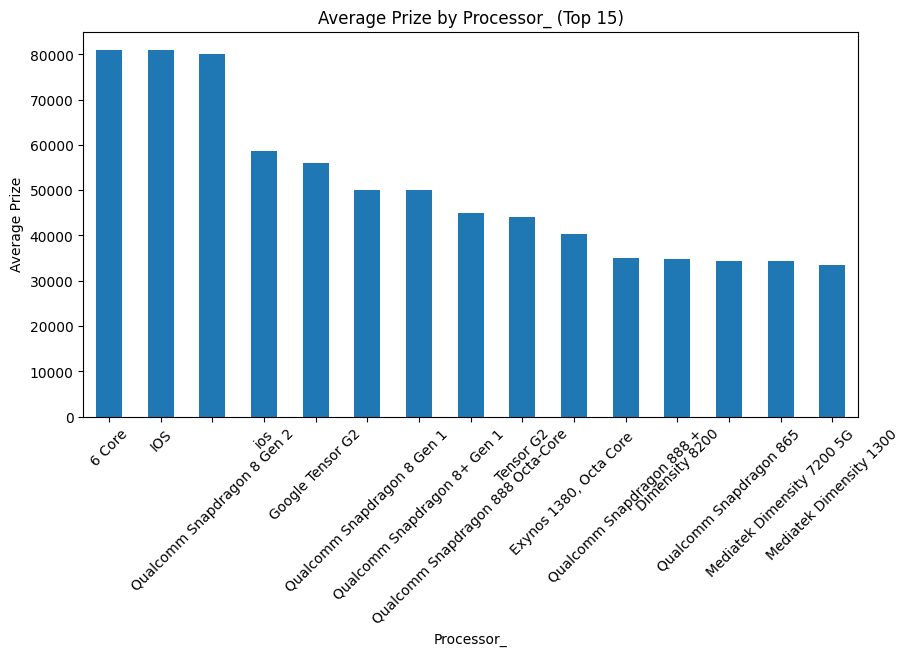

In [ ]:
# =====================================================================
# OBJECTIVE 6.3 : BIVARIATE ANALYSIS
# =====================================================================

print("\n=== OBJECTIVE 6.3: BIVARIATE ANALYSIS ===")

# A. Numerical vs Numerical - Scatter plots
numeric_features = [
    "Memory",
    "RAM",
    "Battery_",
    "Rear Camera",
    "Front Camera",
    "AI Lens",
    "Mobile Height"
]

numeric_features = [col for col in numeric_features if col in df.columns]

for col in numeric_features:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=col, y="Prize")
    plt.title(f"Scatter plot: {col} vs Prize")
    plt.xlabel(col)
    plt.ylabel("Prize")
    plt.show()

# B. Numerical vs Numerical - Regression plots
for col in numeric_features:
    plt.figure(figsize=(7, 5))
    sns.regplot(
        data=df,
        x=col,
        y="Prize",
        scatter_kws={"alpha": 0.5}
    )
    plt.title(f"Regression Plot: {col} vs Prize")
    plt.xlabel(col)
    plt.ylabel("Prize")
    plt.show()

# C. Categorical vs Numerical - Box plots
categorical_features = [
    "Colour",
    "Processor_"
]

categorical_features = [col for col in categorical_features if col in df.columns]

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=col, y="Prize")
    plt.title(f"{col} vs Prize")
    plt.xlabel(col)
    plt.ylabel("Prize")
    plt.xticks(rotation=45)
    plt.show()

# D. Categorical vs Numerical - Average price
for col in categorical_features:
    average_price = df.groupby(col)["Prize"].mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    average_price.head(15).plot(kind="bar")
    plt.title(f"Average Prize by {col} (Top 15)")
    plt.xlabel(col)
    plt.ylabel("Average Prize")
    plt.xticks(rotation=45)
    plt.show()

# E. Categorical vs Categorical - Count plot
if len(categorical_features) >= 2:
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df,
        x=categorical_features[0],
        hue=categorical_features[1]
    )
    plt.title(f"{categorical_features[0]} vs {categorical_features[1]}")
    plt.xlabel(categorical_features[0])
    plt.ylabel("Number of Phones")
    plt.xticks(rotation=45)
    plt.show()



=== OBJECTIVE 6.4: MULTIVARIATE ANALYSIS ===


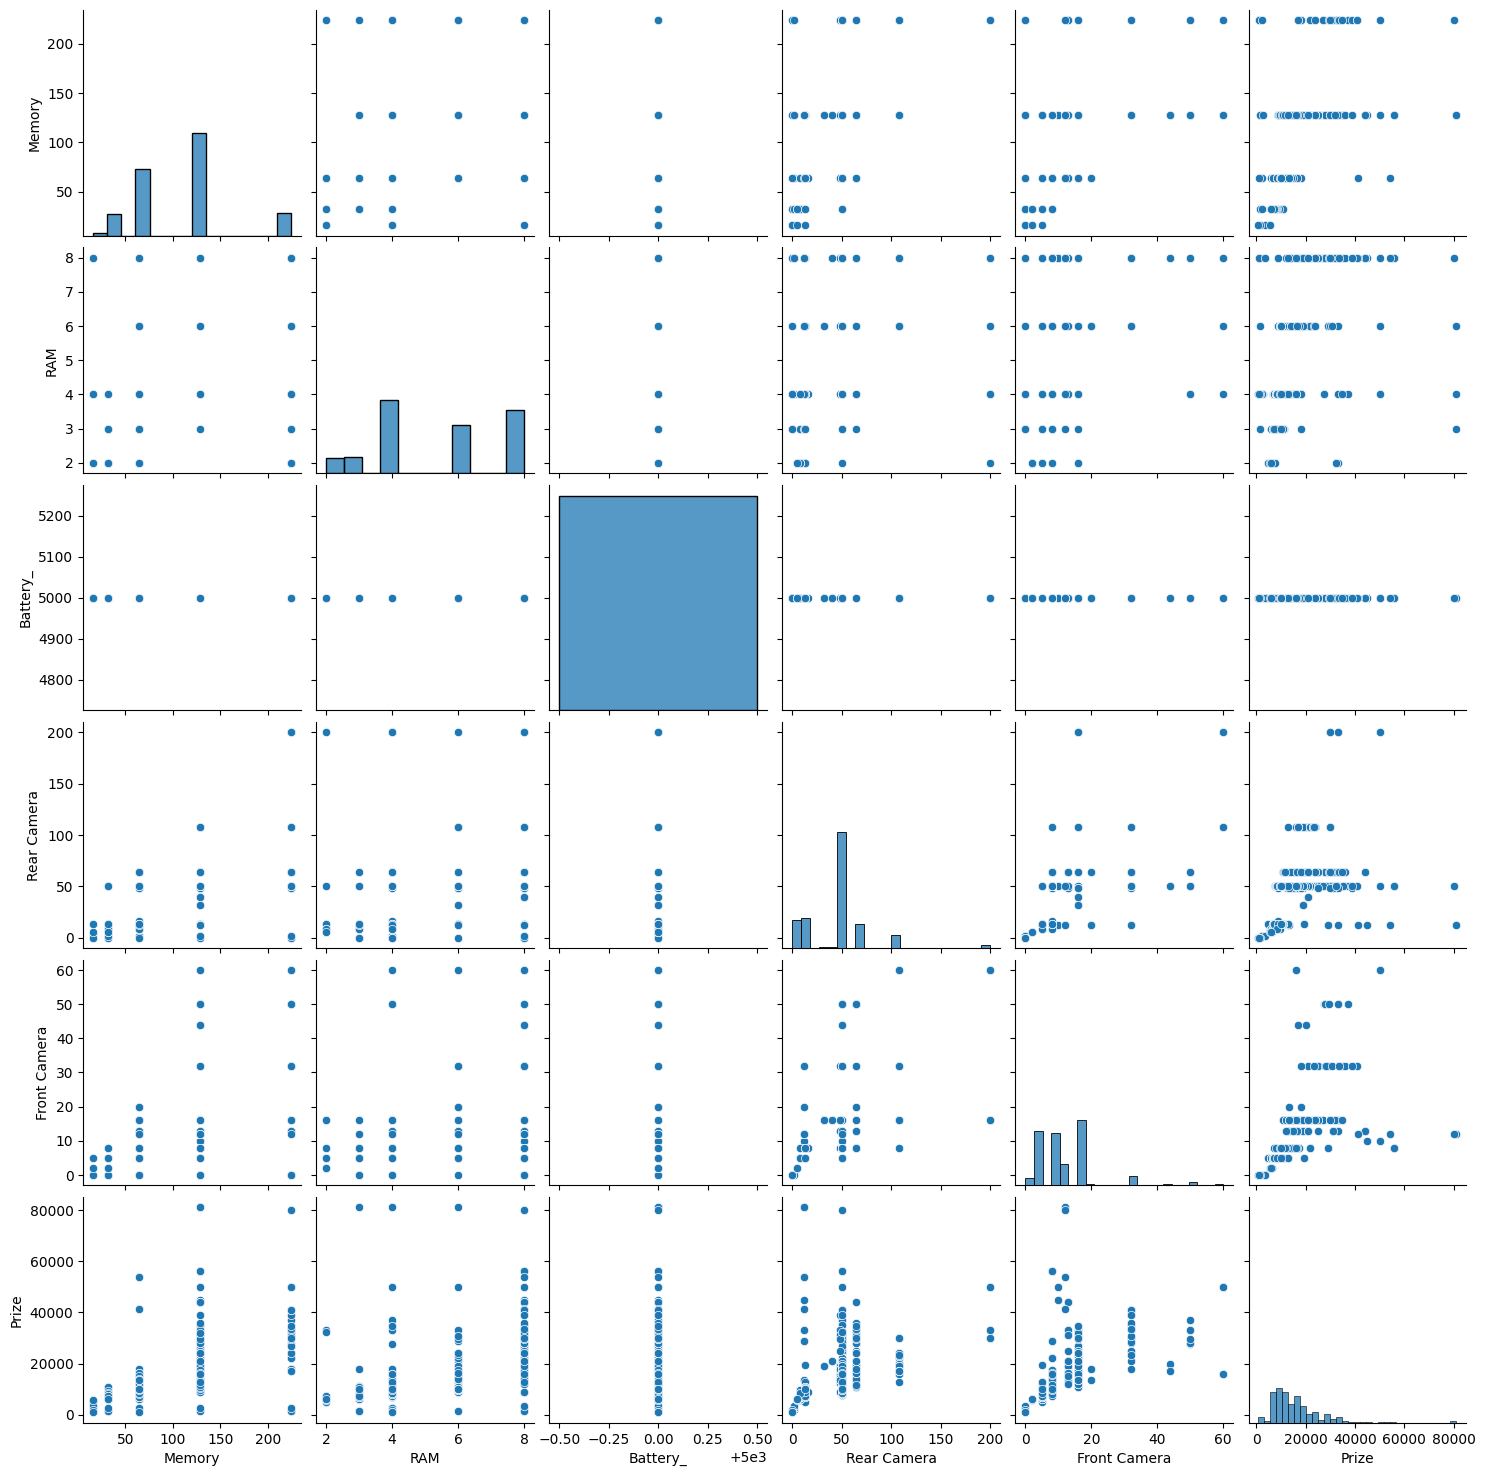

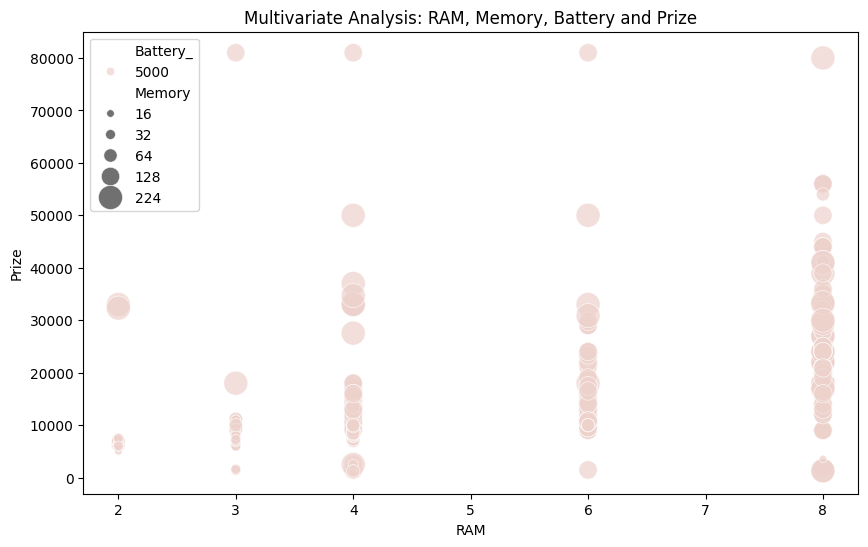

In [ ]:
# =====================================================================
# OBJECTIVE 6.4 : MULTIVARIATE ANALYSIS
# =====================================================================

print("\n=== OBJECTIVE 6.4: MULTIVARIATE ANALYSIS ===")

# A. Pairplot
selected_cols = [
    "Memory",
    "RAM",
    "Battery_",
    "Rear Camera",
    "Front Camera",
    "Prize"
]

selected_cols = [col for col in selected_cols if col in df.columns]

pair_data = df[selected_cols].copy()

for col in selected_cols:
    pair_data[col] = pd.to_numeric(pair_data[col], errors="coerce")

pair_data = pair_data.dropna()

sns.pairplot(pair_data)
plt.show()

# B. Multivariate scatter plot
multi_cols = ["RAM", "Prize", "Memory", "Battery_"]

if all(col in df.columns for col in multi_cols):
    multi_data = df[multi_cols].copy()

    for col in multi_cols:
        multi_data[col] = pd.to_numeric(multi_data[col], errors="coerce")

    multi_data = multi_data.dropna()

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=multi_data,
        x="RAM",
        y="Prize",
        size="Memory",
        hue="Battery_",
        sizes=(30, 300),
        alpha=0.7
    )

    plt.title("Multivariate Analysis: RAM, Memory, Battery and Prize")
    plt.xlabel("RAM")
    plt.ylabel("Prize")
    plt.show()


In [ ]:
# =====================================================================
# OBJECTIVE 7 : DATA PREPROCESSING - ONE-HOT ENCODING
# =====================================================================

print("\n=== OBJECTIVE 7: DATA PREPROCESSING ===")

# Identify categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

# One-hot encoding is used because Model, Colour and Processor are nominal categories.
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)

print("\nShape after one-hot encoding:", df_encoded.shape)
print("\nEncoded dataset:")
print(df_encoded.head())



=== OBJECTIVE 7: DATA PREPROCESSING ===
Categorical columns:
['Model', 'Colour', 'Processor_']

Shape after one-hot encoding: (531, 593)

Encoded dataset:
   Memory  RAM  Battery_  Rear Camera  Front Camera  AI Lens  Mobile Height  \
0      64    4      5000           13             5        0          16.76   
1      64    4      5000           13             5        0          16.76   
2     128    8      5000           50            16        0          16.64   
3      32    2      5000            8             5        0          16.56   
4     128    8      5000           50             5        0          16.76   

   Prize  Model_APPLE iPhone 11  Model_APPLE iPhone 12  ...  \
0   7299                      0                      0  ...   
1   7299                      0                      0  ...   
2  11999                      0                      0  ...   
3   5649                      0                      0  ...   
4   8999                      0                      0

In [12]:
# =====================================================================
# OBJECTIVE 8 : FEATURE ENGINEERING / PREPARATION
# =====================================================================

print("\n=== OBJECTIVE 8: FEATURE ENGINEERING / PREPARATION ===")

# Ensure all columns are numeric and ready for correlation/model building
df_encoded = df_encoded.apply(pd.to_numeric, errors="coerce")
df_encoded.dropna(inplace=True)

print("Final dataset shape before feature extraction:", df_encoded.shape)
print("\nData types:")
print(df_encoded.dtypes)



=== OBJECTIVE 8: FEATURE ENGINEERING / PREPARATION ===
Final dataset shape before feature extraction: (531, 593)

Data types:
Memory                                    int64
RAM                                       int64
Battery_                                  int64
Rear Camera                             float64
Front Camera                            float64
                                         ...   
Processor__Unisoc T616                    int64
Processor__Unisoc Tiger T612 (12 nm)      int64
Processor__Unisoc Tiger T616              int64
Processor__ios                            int64
Processor__snapdragon 888                 int64
Length: 593, dtype: object



=== OBJECTIVE 9: FEATURE EXTRACTION ===


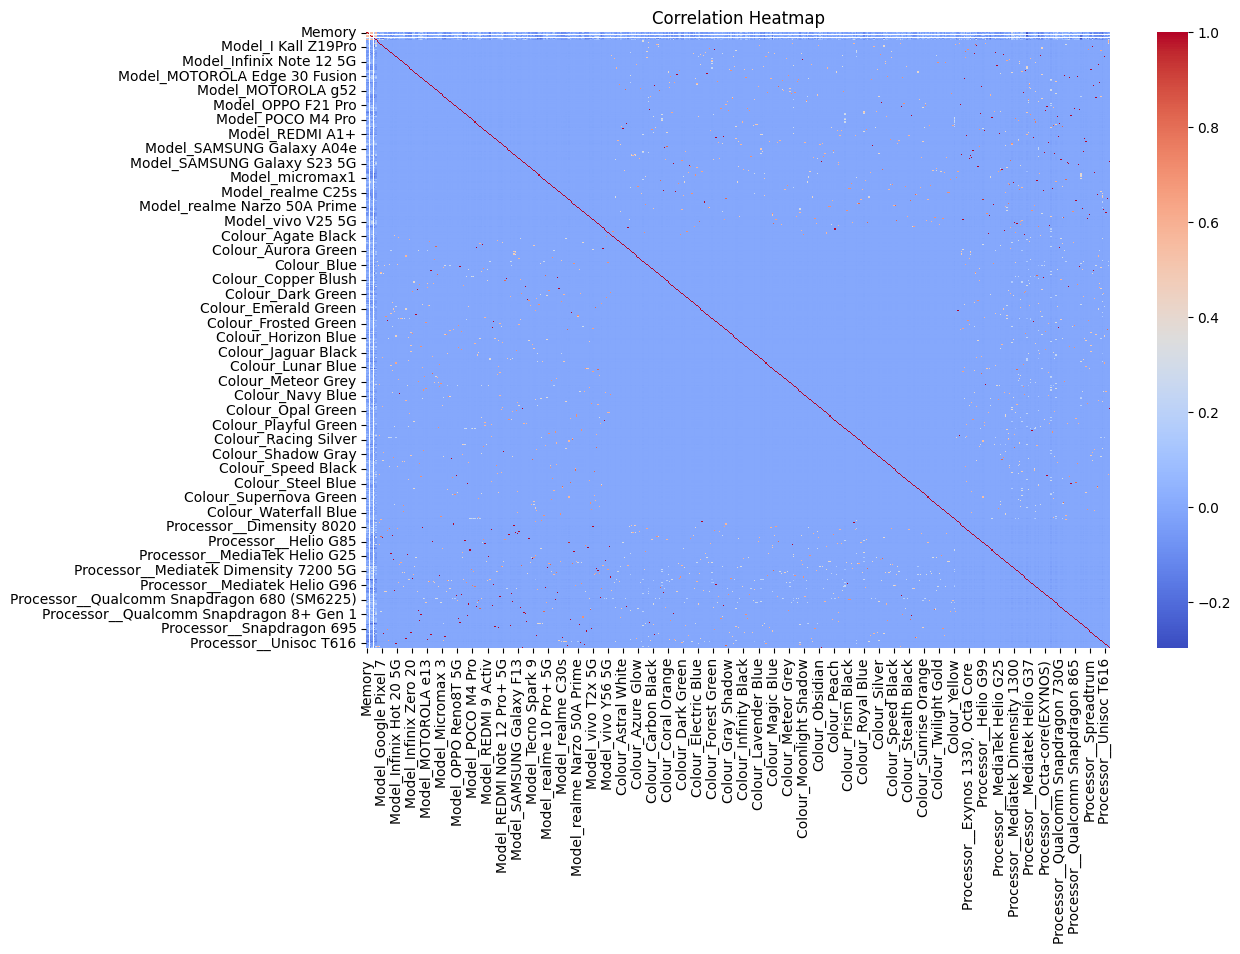


=== TOP FEATURES CORRELATED WITH PRIZE ===
Memory                         0.576794
Front Camera                   0.575623
RAM                            0.529474
Model_APPLE iPhone 14 Plus     0.449988
Rear Camera                    0.392901
Processor__ios                 0.295107
Processor__Google Tensor G2    0.276095
Model_Google Pixel 7           0.276095
Processor__IOS                 0.259310
Colour_Purple                  0.259310
Name: Prize, dtype: float64


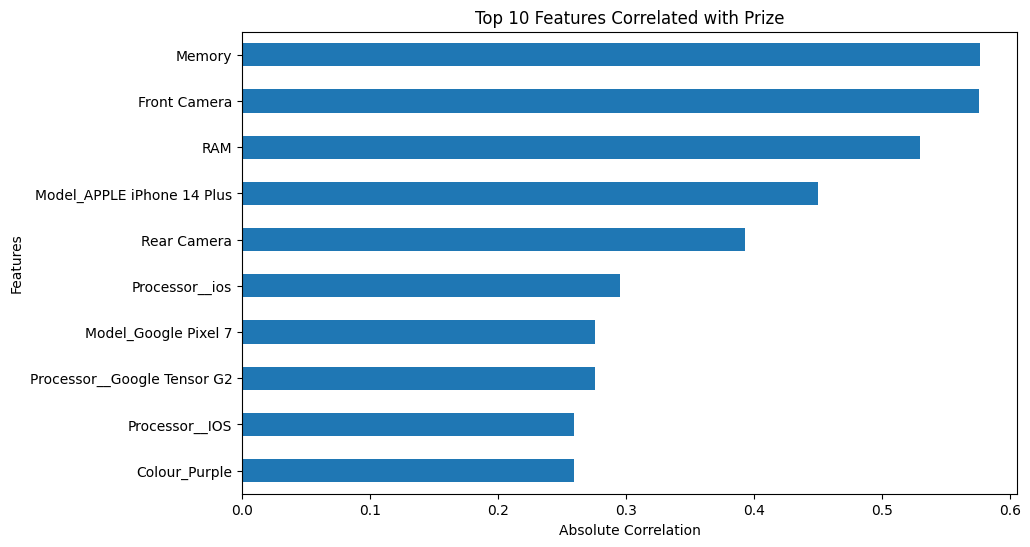

In [13]:
# =====================================================================
# OBJECTIVE 9 : FEATURE EXTRACTION
# CORRELATION ANALYSIS
# =====================================================================

print("\n=== OBJECTIVE 9: FEATURE EXTRACTION ===")

correlation = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=False,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

# Correlation of each feature with the target
target_correlation = (
    correlation["Prize"]
    .drop("Prize")
    .abs()
    .sort_values(ascending=False)
)

print("\n=== TOP FEATURES CORRELATED WITH PRIZE ===")
print(target_correlation.head(10))

# Display the top 10 features in a graph
plt.figure(figsize=(10, 6))
target_correlation.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Features Correlated with Prize")
plt.xlabel("Absolute Correlation")
plt.ylabel("Features")
plt.show()


In [14]:
# =====================================================================
# OBJECTIVE 10 : DEFINE X AND Y
# =====================================================================

print("\n=== OBJECTIVE 10: DEFINE FEATURES AND TARGET ===")

x = df_encoded.drop("Prize", axis=1)
y = df_encoded["Prize"]

print("X shape:", x.shape)
print("Y shape:", y.shape)



=== OBJECTIVE 10: DEFINE FEATURES AND TARGET ===
X shape: (531, 592)
Y shape: (531,)


In [15]:
# =====================================================================
# OBJECTIVE 11 : TRAIN-TEST SPLIT
# =====================================================================

print("\n=== OBJECTIVE 11: TRAIN-TEST SPLIT ===")

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



=== OBJECTIVE 11: TRAIN-TEST SPLIT ===
x_train shape: (424, 592)
x_test shape: (107, 592)
y_train shape: (424,)
y_test shape: (107,)


In [16]:
# =====================================================================
# OBJECTIVE 12 : MODEL BUILDING
# LINEAR REGRESSION
# =====================================================================

print("\n=== OBJECTIVE 12: MODEL BUILDING - LINEAR REGRESSION ===")

model = LinearRegression()
model.fit(x_train, y_train)

print("Linear Regression model trained successfully.")



=== OBJECTIVE 12: MODEL BUILDING - LINEAR REGRESSION ===
Linear Regression model trained successfully.


In [17]:
# =====================================================================
# OBJECTIVE 13 : PREDICTION
# =====================================================================

print("\n=== OBJECTIVE 13: PREDICTION ===")

prediction = model.predict(x_test)

result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": prediction
})

print(result.head(10))



=== OBJECTIVE 13: PREDICTION ===
   Actual Price  Predicted Price
0         23999     24671.129877
1          8999      9476.408322
2         43999     44723.746844
3          8499      8664.068739
4          9999     10965.036209
5          9999      9027.873543
6         14499     14329.029913
7         15999     18459.720587
8         17999     16499.107291
9          6999      7701.615992


In [18]:
# =====================================================================
# OBJECTIVE 14 : MODEL EVALUATION
# =====================================================================

print("\n=== OBJECTIVE 14: MODEL EVALUATION ===")

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)



=== OBJECTIVE 14: MODEL EVALUATION ===
Mean Absolute Error (MAE): 2708.164081415078
Root Mean Squared Error (RMSE): 7024.1547951248585
R2 Score: 0.5320392126023581



=== OBJECTIVE 15: FEATURE IMPORTANCE - RANDOM FOREST ===

=== FEATURE IMPORTANCE RANKING ===
 Rank                                                Feature   Importance
    1                                           Front Camera 3.922701e-01
    2                             Model_APPLE iPhone 14 Plus 1.517959e-01
    3                                                 Memory 8.473642e-02
    4                                                    RAM 7.284388e-02
    5                                   Model_Google Pixel 7 5.195361e-02
    6                            Processor__Google Tensor G2 4.809002e-02
    7                                            Rear Camera 4.288839e-02
    8                                          Mobile Height 2.401301e-02
    9                Processor__Qualcomm Snapdragon 8+ Gen 1 6.781937e-03
   10                           Model_MOTOROLA Edge 30 Ultra 6.183279e-03
   11                   Processor__Qualcomm Snapdragon 778G+ 4.703773e-03
   12             

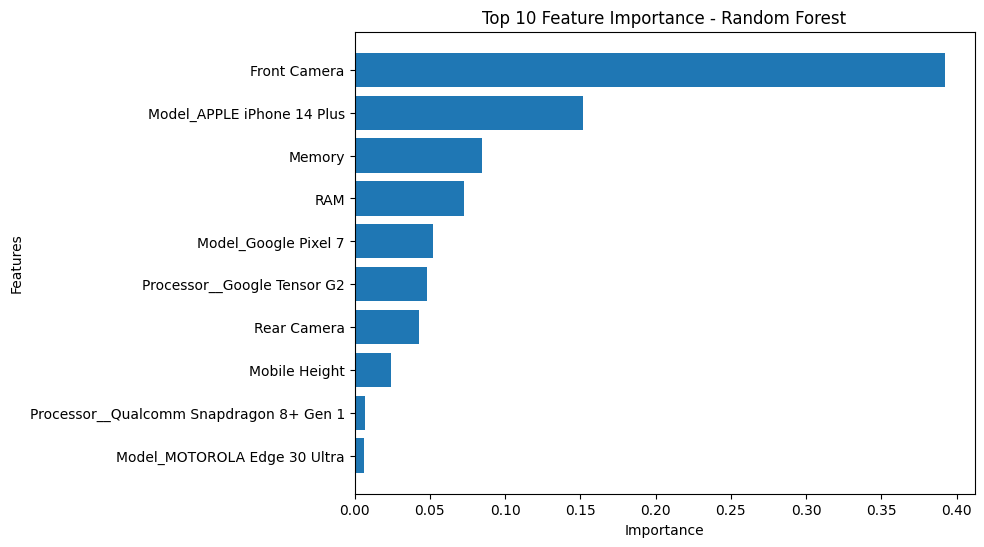

In [19]:
# =====================================================================
# OBJECTIVE 15 : FEATURE IMPORTANCE
# RANDOM FOREST MODEL
# =====================================================================

print("\n=== OBJECTIVE 15: FEATURE IMPORTANCE - RANDOM FOREST ===")

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(x_train, y_train)

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Add Rank column
feature_importance.insert(
    0,
    "Rank",
    range(1, len(feature_importance) + 1)
)

print("\n=== FEATURE IMPORTANCE RANKING ===")
print(feature_importance.to_string(index=False))

# Plot top 10 features
top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance - Random Forest")
plt.show()


In [20]:
# =====================================================================
# OBJECTIVE 16 : FINAL RECOMMENDATIONS
# =====================================================================

print("\n=== OBJECTIVE 16: FINAL RECOMMENDATIONS ===")

top_5_features = feature_importance.head(5)

print("Top 5 influential features based on Random Forest:")
print(top_5_features[["Rank", "Feature", "Importance"]].to_string(index=False))

print("\nRecommendations:")
print("1. Give greater attention to the highest-ranked features when setting mobile phone prices.")
print("2. Use RAM, memory/storage and other highly ranked hardware specifications when comparing products.")
print("3. Use the feature-importance ranking to support pricing and marketing decisions.")
print("4. Combine model predictions with business knowledge before making final pricing decisions.")
print("5. Monitor feature importance periodically as the mobile phone market changes.")



=== OBJECTIVE 16: FINAL RECOMMENDATIONS ===
Top 5 influential features based on Random Forest:
 Rank                    Feature  Importance
    1               Front Camera    0.392270
    2 Model_APPLE iPhone 14 Plus    0.151796
    3                     Memory    0.084736
    4                        RAM    0.072844
    5       Model_Google Pixel 7    0.051954

Recommendations:
1. Give greater attention to the highest-ranked features when setting mobile phone prices.
2. Use RAM, memory/storage and other highly ranked hardware specifications when comparing products.
3. Use the feature-importance ranking to support pricing and marketing decisions.
4. Combine model predictions with business knowledge before making final pricing decisions.
5. Monitor feature importance periodically as the mobile phone market changes.


In [21]:
# =====================================================================
# FINAL PROJECT SUMMARY
# =====================================================================

print("\n" + "=" * 70)
print("PROJECT COMPLETED")
print("=" * 70)

print("Dataset shape after preprocessing:", df_encoded.shape)
print("Linear Regression MAE:", round(mae, 2))
print("Linear Regression RMSE:", round(rmse, 2))
print("Linear Regression R2 Score:", round(r2, 4))

print("\nTop 5 influential features:")
print(feature_importance.head(5)[["Rank", "Feature", "Importance"]].to_string(index=False))



PROJECT COMPLETED
Dataset shape after preprocessing: (531, 593)
Linear Regression MAE: 2708.16
Linear Regression RMSE: 7024.15
Linear Regression R2 Score: 0.532

Top 5 influential features:
 Rank                    Feature  Importance
    1               Front Camera    0.392270
    2 Model_APPLE iPhone 14 Plus    0.151796
    3                     Memory    0.084736
    4                        RAM    0.072844
    5       Model_Google Pixel 7    0.051954
